The Elliptic Dataset is a graph network of Bitcoin transactions with handcrafted features. This guide provides Jupyter notebook code for preprocessing the dataset.

## Dataset Structure

The Elliptic dataset consists of three main CSV files:
- `elliptic_txs_features.csv`: Contains transaction features (203,769 transactions)
- `elliptic_txs_classes.csv`: Contains transaction labels (licit, illicit, unknown)
- `elliptic_txs_edgelist.csv`: Contains graph edges/connections between transactions

### Feature Description
- **Column 0**: Transaction ID
- **Column 1**: Time step (49 total, ~2 weeks interval each, covering ~2 years)
- **Columns 2-94**: 93 transaction features
  - Number of inputs/outputs
  - Transaction fee
  - Output volume
  - Average BTC received/spent by inputs/outputs
  - Average number of incoming/outgoing transactions
- **Columns 95-166**: 72 aggregated features
  - One-hop backward/forward neighborhood statistics
  - Maximum, minimum, standard deviation, correlation coefficients

### Class Labels
- **'1'**: Illicit transactions
- **'2'**: Licit transactions
- **Unlabeled**: Unknown transactions


In [ ]:

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


df_classes = pd.read_csv('elliptic_txs_classes.csv')
df_features = pd.read_csv('elliptic_txs_features.csv', header=None)
df_edgelist = pd.read_csv('elliptic_txs_edgelist.csv')

print(f"Classes shape: {df_classes.shape}")
print(f"Features shape: {df_features.shape}")
print(f"Edgelist shape: {df_edgelist.shape}")



Classes shape: (203769, 2)
Features shape: (102461, 167)
Edgelist shape: (234355, 2)


In [ ]:
df_features.columns = ['id', 'time_step'] + [f'trans_feat_{i}' for i in range(93)] + [f'agg_feat_{i}' for i in range(72)]
print(df_features.head())
print(df_features.info())

          id  time_step  trans_feat_0  trans_feat_1  trans_feat_2  \
0  230425980          1     -0.171469     -0.184668     -1.201369   
1    5530458          1     -0.171484     -0.184668     -1.201369   
2  232022460          1     -0.172107     -0.184668     -1.201369   
3  232438397          1      0.163054      1.963790     -0.646376   
4  230460314          1      1.011523     -0.081127     -1.201369   

   trans_feat_3  trans_feat_4  trans_feat_5  trans_feat_6  trans_feat_7  ...  \
0     -0.121970     -0.043875     -0.113002     -0.061584     -0.162097  ...   
1     -0.121970     -0.043875     -0.113002     -0.061584     -0.162112  ...   
2     -0.121970     -0.043875     -0.113002     -0.061584     -0.162749  ...   
3     12.409294     -0.063725      9.782742     12.414558     -0.163645  ...   
4      1.153668      0.333276      1.312656     -0.061584     -0.163523  ...   

   agg_feat_62  agg_feat_63  agg_feat_64  agg_feat_65  agg_feat_66  \
0    -0.562153    -0.600999     1.

In [ ]:
df_merged = pd.merge(df_features, df_classes, left_on='id', right_on='txId', how='left')
print("Class distribution:")
print(df_merged['class'].value_counts())
print("\nClass proportions:")
print(df_merged['class'].value_counts(normalize=True))

Class distribution:
class
unknown    80511
2          19899
1           2051
Name: count, dtype: int64

Class proportions:
class
unknown    0.785772
2          0.194210
1          0.020017
Name: proportion, dtype: float64


In [ ]:
print("Missing values per column:")
print(df_merged.isnull().sum())


df_merged['class'] = df_merged['class'].fillna('unknown')


df_labeled = df_merged[df_merged['class'] != 'unknown'].copy()
print(f"\nDataset shape after filtering: {df_labeled.shape}")

Missing values per column:
id              0
time_step       0
trans_feat_0    0
trans_feat_1    0
trans_feat_2    0
               ..
agg_feat_69     1
agg_feat_70     1
agg_feat_71     1
txId            0
class           0
Length: 169, dtype: int64

Dataset shape after filtering: (21950, 169)


In [ ]:
feature_cols = [col for col in df_merged.columns if col.startswith('trans_feat_') or col.startswith('agg_feat_')]
X = df_merged[feature_cols].copy()
y = df_merged['class'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature matrix shape: (102461, 165)
Target shape: (102461,)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)
X_minmax_df = pd.DataFrame(X_minmax, columns=feature_cols)

print("Scaled features statistics:")
print(f"Mean: {X_scaled.mean():.6f}")
print(f"Std: {X_scaled.std():.6f}")
print(f"Min: {X_scaled.min():.6f}")
print(f"Max: {X_scaled.max():.6f}")

Scaled features statistics:
Mean: nan
Std: nan
Min: nan
Max: nan


In [ ]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


non_outliers = ~((X < lower_bound) | (X > upper_bound)).any(axis=1)
print(f"Number of outliers: {(~non_outliers).sum()}")
print(f"Percentage of outliers: {(~non_outliers).sum() / len(X) * 100:.2f}%")

Number of outliers: 97596
Percentage of outliers: 95.25%


In [ ]:
X_labeled = X[y != 'unknown']
y_labeled = y[y != 'unknown']


y_encoded = (y_labeled == '1').astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    X_labeled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Class distribution in training set:")
print(y_train.value_counts())

Training set size: 17560
Test set size: 4390
Class distribution in training set:
class
0    15919
1     1641
Name: count, dtype: int64


In [ ]:

time_steps = df_merged.loc[X.index, 'time_step']


train_mask = time_steps <= time_steps.quantile(0.8)
X_train_temporal = X[train_mask]
X_test_temporal = X[~train_mask]
y_train_temporal = y[train_mask]
y_test_temporal = y[~train_mask]

print(f"Training set size (temporal): {X_train_temporal.shape[0]}")
print(f"Test set size (temporal): {X_test_temporal.shape[0]}")


Training set size (temporal): 82965
Test set size (temporal): 19496


In [ ]:
G = nx.DiGraph()


for node_id in df_merged['id']:
    G.add_node(node_id)


for _, row in df_edgelist.iterrows():
    G.add_edge(row['txId1'], row['txId2'])

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")


from scipy.sparse import csr_matrix
adjacency_matrix = nx.adjacency_matrix(G)
print(f"Adjacency matrix shape: {adjacency_matrix.shape}")

Number of nodes: 203769
Number of edges: 234355
Adjacency matrix shape: (203769, 203769)


Feature statistics:
        trans_feat_0   trans_feat_1   trans_feat_2   trans_feat_3  \
count  102461.000000  102461.000000  102461.000000  102461.000000   
mean       -0.000611      -0.138583      -0.497500       0.000401   
std         0.641589       0.231750       0.923151       0.974219   
min        -0.172983      -0.210553      -1.756361      -0.121970   
25%        -0.172308      -0.184668      -1.201369      -0.121970   
50%        -0.168342      -0.177453      -1.201369      -0.121970   
75%        -0.131543      -0.132897       0.463609      -0.046932   
max        46.390131      25.674475       2.128587      49.027598   

        trans_feat_4   trans_feat_5   trans_feat_6   trans_feat_7  \
count  102461.000000  102461.000000  102461.000000  102461.000000   
mean        0.000228      -0.003911       0.013545      -0.000819   
std         1.169746       0.959950       0.983364       0.634991   
min        -0.063725      -0.113002      -0.061584      -0.163646   
25%        -0

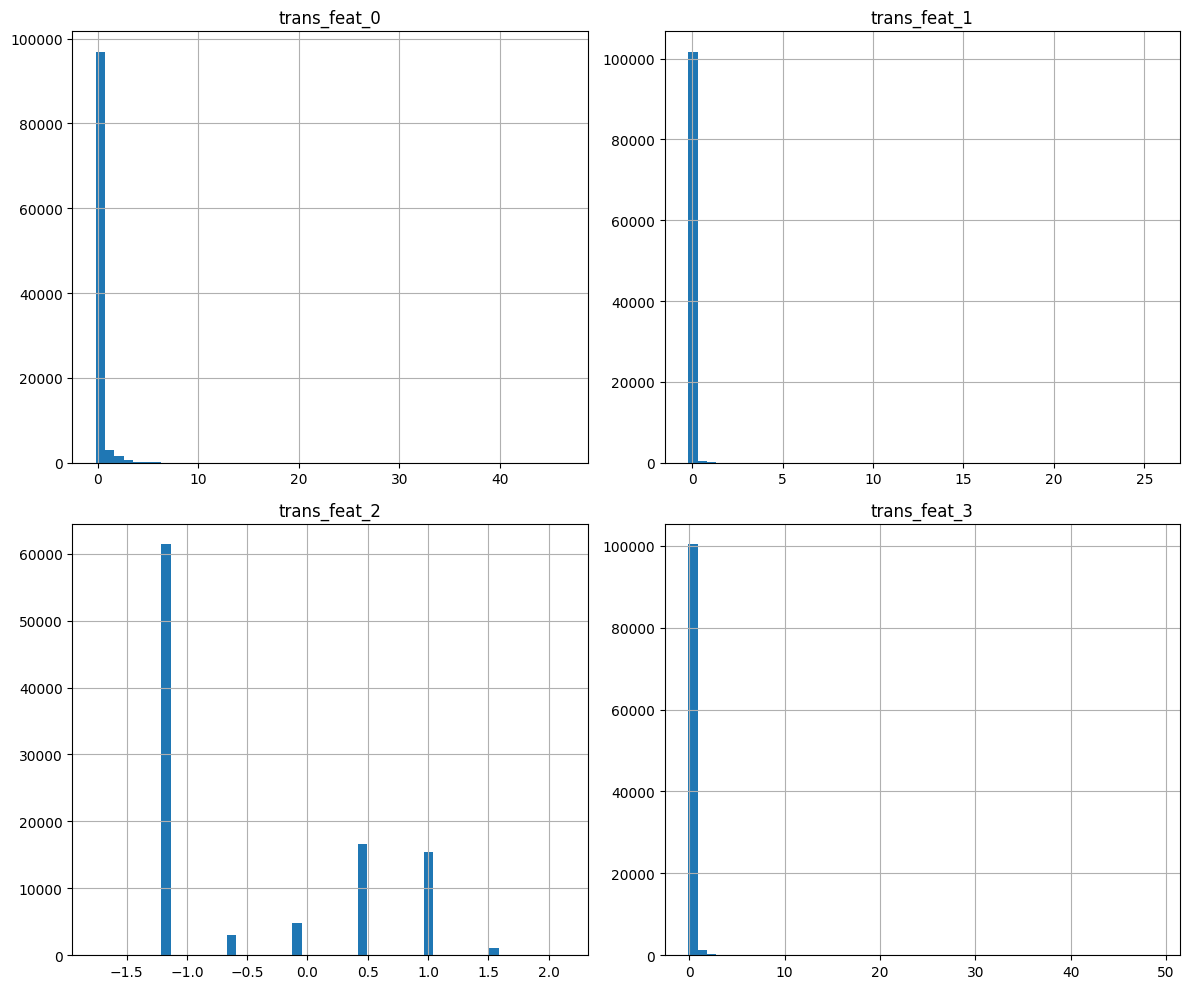


Top correlated feature pairs:
trans_feat_28  trans_feat_22    1.0
trans_feat_22  trans_feat_28    1.0
trans_feat_23  trans_feat_29    1.0
trans_feat_29  trans_feat_23    1.0
trans_feat_30  trans_feat_24    1.0
trans_feat_24  trans_feat_30    1.0
trans_feat_27  trans_feat_21    1.0
trans_feat_21  trans_feat_27    1.0
trans_feat_63  trans_feat_57    1.0
trans_feat_57  trans_feat_63    1.0
dtype: float64


In [ ]:
print("Feature statistics:")
print(X.describe())

# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
X[['trans_feat_0', 'trans_feat_1', 'trans_feat_2', 'trans_feat_3']].hist(bins=50, ax=axes.ravel())
plt.tight_layout()
plt.show()

# Correlation analysis
correlation_matrix = X.corr()
print("\nTop correlated feature pairs:")
# Get upper triangle of correlation matrix
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs != 1.0].sort_values(ascending=False)
print(corr_pairs.head(10))

In [ ]:
from collections import Counter
class_counts = Counter(y_encoded)
print(f"Class distribution: {class_counts}")
print(f"Imbalance ratio: {class_counts[1] / class_counts[0]:.4f}")

# Option 1: Use class weights in model training
class_weight = {0: 1, 1: class_counts[0] / class_counts[1]}

# Option 2: Oversample minority class (optional)
from sklearn.utils import resample
X_minority = X_labeled[y_encoded == 1]
y_minority = y_encoded[y_encoded == 1]

X_minority_upsampled, y_minority_upsampled = resample(
    X_minority, y_minority, n_samples=len(X_labeled[y_encoded == 0]), random_state=42
)

X_balanced = pd.concat([X_labeled[y_encoded == 0], X_minority_upsampled])
y_balanced = pd.concat([y_encoded[y_encoded == 0], y_minority_upsampled])

Class distribution: Counter({0: 19899, 1: 2051})
Imbalance ratio: 0.1031


In [ ]:
X_train.to_csv('X_train_preprocessed.csv', index=False)
X_test.to_csv('X_test_preprocessed.csv', index=False)
y_train.to_csv('y_train_preprocessed.csv', index=False)
y_test.to_csv('y_test_preprocessed.csv', index=False)

# Save scaler for future use
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


## Common Preprocessing Techniques

### StandardScaler (Z-score Normalization)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### MinMaxScaler (0-1 Normalization)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


### RobustScaler (for outliers)

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
